# 능동형 데이터 분석 with AI (실행:Gemini 무료)

---
**프롬프트:** 데이터는 `DieCasting_Raw_Data.csv`에 있습니다. pandas로 불러와 `df`에 저장하고, 데이터 크기와 처음 5행을 확인하는 코드를 작성하세요.

In [2]:
import pandas as pd

# 1. 데이터 불러오기
# 파일이 작업 디렉토리에 있다고 가정합니다.
try:
    df = pd.read_csv('DieCasting_Raw_Data.csv')
    
    # 2. 데이터 크기 확인 (행, 열)
    print("데이터 크기(행, 열):", df.shape)
    
    # 3. 처음 5행 확인
    print("\n--- 처음 5행 데이터 ---")
    print(df.head())

except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

데이터 크기(행, 열): (5161, 17)

--- 처음 5행 데이터 ---
   Shot  Velocity_1  Velocity_2  Velocity_3  High_Velocity  Cylinder_Pressure  \
0     1       0.144       0.170       0.188          2.134              214.0   
1     2       0.144       0.170       0.182          2.124              217.0   
2     3       0.144       0.170       0.182          2.116              214.0   
3     4       0.144       0.170       0.182          2.137              217.0   
4     5       0.144       0.172       0.176          2.111              217.0   

   Rapid_Rise_Time  Biscuit_Thickness  Clamping_Force  Cycle_Time  \
0            0.008               10.0           258.0        20.7   
1            0.008               11.0           257.0        20.7   
2            0.008               11.0           257.0        20.8   
3            0.008               11.0           257.0        20.7   
4            0.008               12.0           257.0        20.7   

   Pressure_Rise_Time  Casting_Pressure  Spray_Time  S

**해석:** 데이터 로드 결과에 대한 해석
변수 구성의 균형: 사출 속도(Velocity 1~3, High)와 압력(Cylinder, Casting), 그리고 시간(Rapid Rise, Cycle, Spray) 변수들이 골고루 포함되어 있습니다. 이는 공정의 입력(설정치)과 출력(결과치) 사이의 상관관계를 분석하기에 매우 좋은 구조입니다.

데이터 무결성: 처음 5행을 보면 수치들이 비교적 일정한 범위 내에서 움직이고 있습니다. 다만, 앞서 샘플에서 보았던 Velocity_1의 결측치(7번 Shot) 사례처럼 중간에 비어있는 값이 전체 5,161행 중 얼마나 되는지 확인이 필요해 보입니다.

타겟 변수 후보: Machine_Status가 0으로 나타나는데, 전체 데이터에서 이 값이 변하는 지점이 있다면 그것이 설비의 이상이나 제품의 불량을 판단하는 중요한 타겟(Label)이 될 것입니다.

---
**프롬프트:** `df`에 대해 각 컬럼의 데이터 타입과 결측치 수를 확인하세요. `Machine_Status`의 정상/비정상/결측 분포도 표로 출력하세요.

In [3]:
import pandas as pd

# 1. 컬럼별 데이터 타입 및 결측치 확인
print("### 컬럼별 데이터 정보 및 결측치 수 ###")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum()
})
print(info_df)

# 2. Machine_Status 분포 확인 (결측치 포함)
print("\n### Machine_Status 분포 (정상/비정상/결측) ###")
# dropna=False를 사용하여 결측치까지 포함하여 카운트합니다.
status_dist = df['Machine_Status'].value_counts(dropna=False).reset_index()
status_dist.columns = ['Status_Value', 'Count']

# 가독성을 위해 상태 라벨링 (0: 정상, 1: 비정상 등으로 가정, 실제 데이터에 맞게 조정 가능)
status_dist['Description'] = status_dist['Status_Value'].map({
    0.0: '정상(Normal)', 
    1.0: '비정상(Abnormal)'
}).fillna('결측(Missing)')

print(status_dist[['Status_Value', 'Description', 'Count']])

### 컬럼별 데이터 정보 및 결측치 수 ###
                   Data Type  Missing Values
Shot                   int64               0
Velocity_1           float64             410
Velocity_2           float64             409
Velocity_3           float64             409
High_Velocity        float64             409
Cylinder_Pressure    float64             409
Rapid_Rise_Time      float64             409
Biscuit_Thickness    float64             409
Clamping_Force       float64             409
Cycle_Time           float64             409
Pressure_Rise_Time   float64             409
Casting_Pressure     float64             409
Spray_Time           float64             409
Spray_1_Time         float64             409
Spray_2_Time         float64             409
Machine_Status       float64             113
_id                    int64               0

### Machine_Status 분포 (정상/비정상/결측) ###
   Status_Value    Description  Count
0           0.0     정상(Normal)   4930
1           1.0  비정상(Abnormal)    118
2         

**해석:** 데이터 현황 해석 및 인사이트
- 결측치의 패턴성: 대부분의 공정 변수(Velocity, Pressure 등)에서 공통적으로 409~410건의 결측치가 발견되었습니다. 이는 전체 데이터(5,161행)의 약 8% 수준입니다. 특정 시점에 센서 데이터 전체가 누락되었거나, 설비 비가동 시기에 생성된 로그일 가능성이 큽니다.

- 타겟 변수의 불균형: Machine_Status를 보면 정상(0.0) 대비 비정상(1.0)의 비율이 약 42:1로 매우 불균형합니다. 전형적인 이상 탐지(Anomaly Detection) 데이터셋의 특징을 보이고 있네요.

- 데이터 타입: 모든 공정 변수가 float64로 적절하게 구성되어 있어 바로 수치 분석이 가능합니다. 다만 Machine_Status가 결측치 때문에 float64로 인식되고 있는데, 이후 전처리를 통해 정수형으로 변환하는 것이 깔끔할 것 같습니다.

---
**프롬프트:** `Machine_Status`가 결측인 행은 타깃을 알 수 없으므로 별도로 제외하고, 분석용 `labeled_df`를 만드세요. 정상과 비정상 비율도 확인하세요.

In [4]:
# 1. Machine_Status가 결측치인 행 제외 (라벨링된 데이터만 추출)
labeled_df = df.dropna(subset=['Machine_Status']).copy()

# 2. 분석의 편의를 위해 Machine_Status를 정수형으로 변환
labeled_df['Machine_Status'] = labeled_df['Machine_Status'].astype(int)

# 3. 정상/비정상 데이터 개수 및 비율 확인
counts = labeled_df['Machine_Status'].value_counts()
percents = labeled_df['Machine_Status'].value_counts(normalize=True) * 100

# 4. 결과 출력
status_summary = pd.DataFrame({
    'Count': counts,
    'Percentage(%)': percents
})
status_summary.index = status_summary.index.map({0: 'Normal (0)', 1: 'Abnormal (1)'})

print("### Labeled Data 구성 현황 ###")
print(status_summary)
print(f"\n전체 분석 가능 데이터 수: {len(labeled_df)}행")

### Labeled Data 구성 현황 ###
                Count  Percentage(%)
Machine_Status                      
Normal (0)       4930      97.662441
Abnormal (1)      118       2.337559

전체 분석 가능 데이터 수: 5048행


**해석:** 
- 극심한 클래스 불균형(Class Imbalance): 비정상 데이터의 비율이 **2.34%**에 불과합니다. 이는 전형적인 제조 현장의 데이터 특성으로, 일반적인 분류 알고리즘을 그대로 적용할 경우 모델이 모든 결과를 '정상'으로 예측해버리는 함정에 빠질 위험이 큽니다.

- 분석의 방향성: 이제부터는 2.34%에 해당하는 118건의 비정상 데이터가 나머지 4,930건의 정상 데이터와 통계적으로 유의미하게 구분되는 지점을 찾는 것이 관건입니다. 특정 센서 수치가 임계치를 넘었는지, 혹은 여러 변수의 조합이 이상 징후를 나타내는지 확인해야 합니다.

- 데이터의 충분성: 비정상 샘플이 100건 이상 확보되었으므로, 통계적 가설 검정이나 머신러닝 기법(SMOTE와 같은 오버샘플링 혹은 비용 민감 학습)을 시도해볼 수 있는 기초 체력은 갖춰진 상태입니다.

---
**프롬프트:** 식별자나 타깃으로 보이는 컬럼을 제외하고 측정값 컬럼 목록을 만들어 주세요. 그 측정값 컬럼들의 기초 통계량을 확인하세요.

In [5]:
# 1. 제외할 컬럼 리스트 (식별자 및 타깃)
exclude_cols = ['Shot', '_id', 'Machine_Status']

# 2. 측정값(Features) 컬럼 목록 생성
measure_cols = [col for col in labeled_df.columns if col not in exclude_cols]

# 3. 측정값 컬럼들의 기초 통계량 확인
# 데이터 양이 많으므로 전치(T)하여 보기 편하게 출력합니다.
measure_stats = labeled_df[measure_cols].describe().T

# 4. 분석에 유용한 지표 추가 (변동계수 등)
measure_stats['CV'] = (measure_stats['std'] / measure_stats['mean']) * 100 # 변동계수 (%)
print("### 공정 측정값 기초 통계 요약 ###")
print(measure_stats)

print("\n### 선택된 측정값 컬럼 목록 ###")
print(measure_cols)

### 공정 측정값 기초 통계 요약 ###
                     count        mean         std      min      25%  \
Velocity_1          4721.0    0.147995    0.007054    0.134    0.142   
Velocity_2          4722.0    0.168656    0.004450    0.158    0.166   
Velocity_3          4722.0    0.190805    0.011582    0.172    0.181   
High_Velocity       4722.0    2.301518    0.317231    0.000    2.133   
Cylinder_Pressure   4722.0  237.337357   26.161360   89.000  217.000   
Rapid_Rise_Time     4722.0    0.009504    0.002348    0.000    0.008   
Biscuit_Thickness   4722.0   14.181491    3.396282    0.000   11.000   
Clamping_Force      4722.0  303.811309   56.014888  222.000  255.000   
Cycle_Time          4722.0   32.283715  129.441298   20.200   20.800   
Pressure_Rise_Time  4722.0    0.039969    0.026766    0.000    0.036   
Casting_Pressure    4722.0  858.336722  236.369672  200.000  596.000   
Spray_Time          4722.0    9.658873    1.798648    7.000    8.000   
Spray_1_Time        4722.0    1.399195  

**해석:**
- Cycle_Time의 비정상적 극단치: Cycle_Time의 변동계수(CV)가 **400%**를 넘습니다. 중앙값(50%)은 21.65초인데 최대값이 6,170초에 달한다는 것은 설비 중단, 대기 시간 혹은 데이터 기록 오류가 강력하게 의심되는 지점입니다. 이 변수는 추후 분석에서 스케일링이나 이상치 처리가 반드시 필요해 보입니다.

- 압력 및 속도 제어의 이중 분포 가능성: Casting_Pressure와 Cylinder_Pressure의 중앙값이 75% 분위수(Q3)에 매우 가깝게 형성되어 있습니다. 반면 최소값은 상당히 낮습니다. 이는 대부분의 샷이 높은 압력에서 안정적으로 유지되지만, 특정 구간에서 압력이 급격히 떨어지는 현상이 발생하고 있음을 시사합니다.

- 고속 사출 영역의 변동성: High_Velocity의 최소값이 0인 점이 눈에 띕니다. 고속 사출이 이루어지지 않은 샷이 존재한다는 의미인데, 이것이 Machine_Status의 비정상(1)과 직결되는지 확인해볼 가치가 있습니다.

- 시간 관련 변수의 불안정성: Pressure_Rise_Time, Spray_1_Time, Spray_2_Time의 CV가 상대적으로 높습니다(39%~66%). 특히 Pressure_Rise_Time의 최대값이 1.49로 평균 대비 매우 높게 튀어 있는데, 압력이 형성되는 시간이 길어지는 현상이 품질에 미치는 영향이 클 것으로 보입니다.

- 결측치 잔존: 여전히 측정값 컬럼들의 count가 4,720대인 것으로 보아, Machine_Status는 존재하지만 측정값이 비어있는 행들이 약 300여 건 존재합니다.

---
**프롬프트:** 측정값 컬럼에서 결측이 있는 행과 없는 행을 나누어 보세요. 두 그룹의 비정상 비율을 비교하세요.

In [6]:
# 1. 측정값 컬럼 리스트 (앞서 정의한 measure_cols 사용)
# measure_cols = [...]

# 2. 측정값 중 하나라도 결측이 있는 행과 없는 행 구분
# labeled_df 내에서 측정값 컬럼들에 대해 결측 여부 체크
is_missing = labeled_df[measure_cols].isnull().any(axis=1)

missing_group = labeled_df[is_missing].copy()
complete_group = labeled_df[~is_missing].copy()

# 3. 각 그룹별 비정상(Machine_Status=1) 비율 계산
def get_status_report(group, name):
    count = len(group)
    if count == 0:
        return {f"{name}": "No Data"}
    
    abnormal_count = (group['Machine_Status'] == 1).sum()
    abnormal_rate = (abnormal_count / count) * 100
    return {
        "Group": name,
        "Total Count": count,
        "Abnormal Count": abnormal_count,
        "Abnormal Rate (%)": round(abnormal_rate, 4)
    }

report = pd.DataFrame([
    get_status_report(complete_group, "Complete Data"),
    get_status_report(missing_group, "Missing Data")
])

print("### 데이터 결측 여부에 따른 비정상 비율 비교 ###")
print(report)

### 데이터 결측 여부에 따른 비정상 비율 비교 ###
           Group  Total Count  Abnormal Count  Abnormal Rate (%)
0  Complete Data         4721             104             2.2029
1   Missing Data          327              14             4.2813


**해석:** 
- 비정상 발생 확률의 차이: 측정값이 모두 존재하는 그룹(2.2%)보다 일부라도 결측이 있는 그룹(4.28%)에서 비정상(Abnormal)이 발생할 확률이 약 2배 가량 높게 나타났습니다.

- 센서 데이터와 설비 상태의 연결고리: 데이터가 누락되었다는 현상 자체가 설비의 불안정성이나 데이터 수집 시스템(PLC, DAQ 등)의 일시적 오류를 반영하고 있을 가능성이 큽니다. 즉, "데이터가 찍히지 않는 순간"이 품질 사고로 이어질 위험이 통계적으로 더 높다는 뜻입니다.

- 전략적 시사점: 단순히 결측치를 버리고 분석하기에는 그 안에 담긴 '이상 징후' 정보가 아깝습니다. Missing_Flag 같은 파생 변수를 만들어 "결측 발생 여부" 자체를 모델의 입력 피처로 사용하는 전략이 유효해 보입니다.


---
**프롬프트:** 측정값 결측이 한 행에서 몇 개씩 동시에 발생하는지 확인하세요. 결측 개수별 행 수와 비정상 비율을 표로 보여주세요.

In [7]:
# 1. 각 행별 결측치 개수 계산
labeled_df['missing_count'] = labeled_df[measure_cols].isnull().sum(axis=1)

# 2. 결측 개수별 행 수(Count)와 비정상(Abnormal) 수 계산
missing_stats = labeled_df.groupby('missing_count').agg(
    Total_Count=('Machine_Status', 'count'),
    Abnormal_Count=('Machine_Status', lambda x: (x == 1).sum())
).reset_index()

# 3. 비정상 비율(%) 계산
missing_stats['Abnormal_Rate(%)'] = (missing_stats['Abnormal_Count'] / missing_stats['Total_Count']) * 100

print("### 결측치 개수별 비정상 비율 상세 분석 ###")
print(missing_stats.sort_values(by='missing_count'))

### 결측치 개수별 비정상 비율 상세 분석 ###
   missing_count  Total_Count  Abnormal_Count  Abnormal_Rate(%)
0              0         4721             104          2.202923
1              1            1               0          0.000000
2             14          326              14          4.294479


**해석:**
- 시스템 셧다운 혹은 통신 단절: 결측치가 14개인 행이 326건이라는 것은, 특정 시점에 모든 센서 데이터의 수집이 동시에 중단되었음을 의미합니다. 이는 설비의 전원 오프(Power-off), 통신 게이트웨이 오류, 또는 PLC 데이터 전송 중단과 같은 시스템 수준의 공백입니다.

- "침묵" 속의 위험: 모든 측정값이 누락된 상태(missing_count 14)에서의 비정상 비율(4.29%)이 데이터가 온전한 상태(2.20%)보다 약 1.95배 높습니다. 데이터가 기록되지 않는 순간에 실제 공정 사고나 품질 이상이 발생할 확률이 훨씬 높다는 데이터적 증거입니다.

- 단일 결측의 희소성: 결측치가 딱 1개인 행은 단 1건뿐입니다. 이는 개별 센서의 고장보다는 시스템 전체의 동기화 문제가 주된 결측 원인임을 시사합니다.

데이터 처리 전략 제안
현재 상황에서 비정상(Abnormal) 데이터 118건 중 14건은 측정값이 전혀 없는 상태입니다.

- 분석의 엄밀성: 측정값이 없는 14건의 비정상 데이터는 '원인 분석'을 위한 변수(속도, 압력 등)가 없으므로, 상관관계나 인과관계 모델링에서는 제외하는 것이 타당합니다.

- 실전 대응: 다만, 현장 운영 측면에서는 "데이터 수집이 중단되는 현상" 자체를 설비 이상을 알리는 강력한 조기 경보(Early Warning) 지표로 활용할 필요가 있습니다.


---
**프롬프트:** 측정값 컬럼들의 분포를 히스토그램으로 확인하세요. 분포가 치우쳤거나 이상치가 커 보이는 변수도 눈으로 볼 수 있게 해주세요.

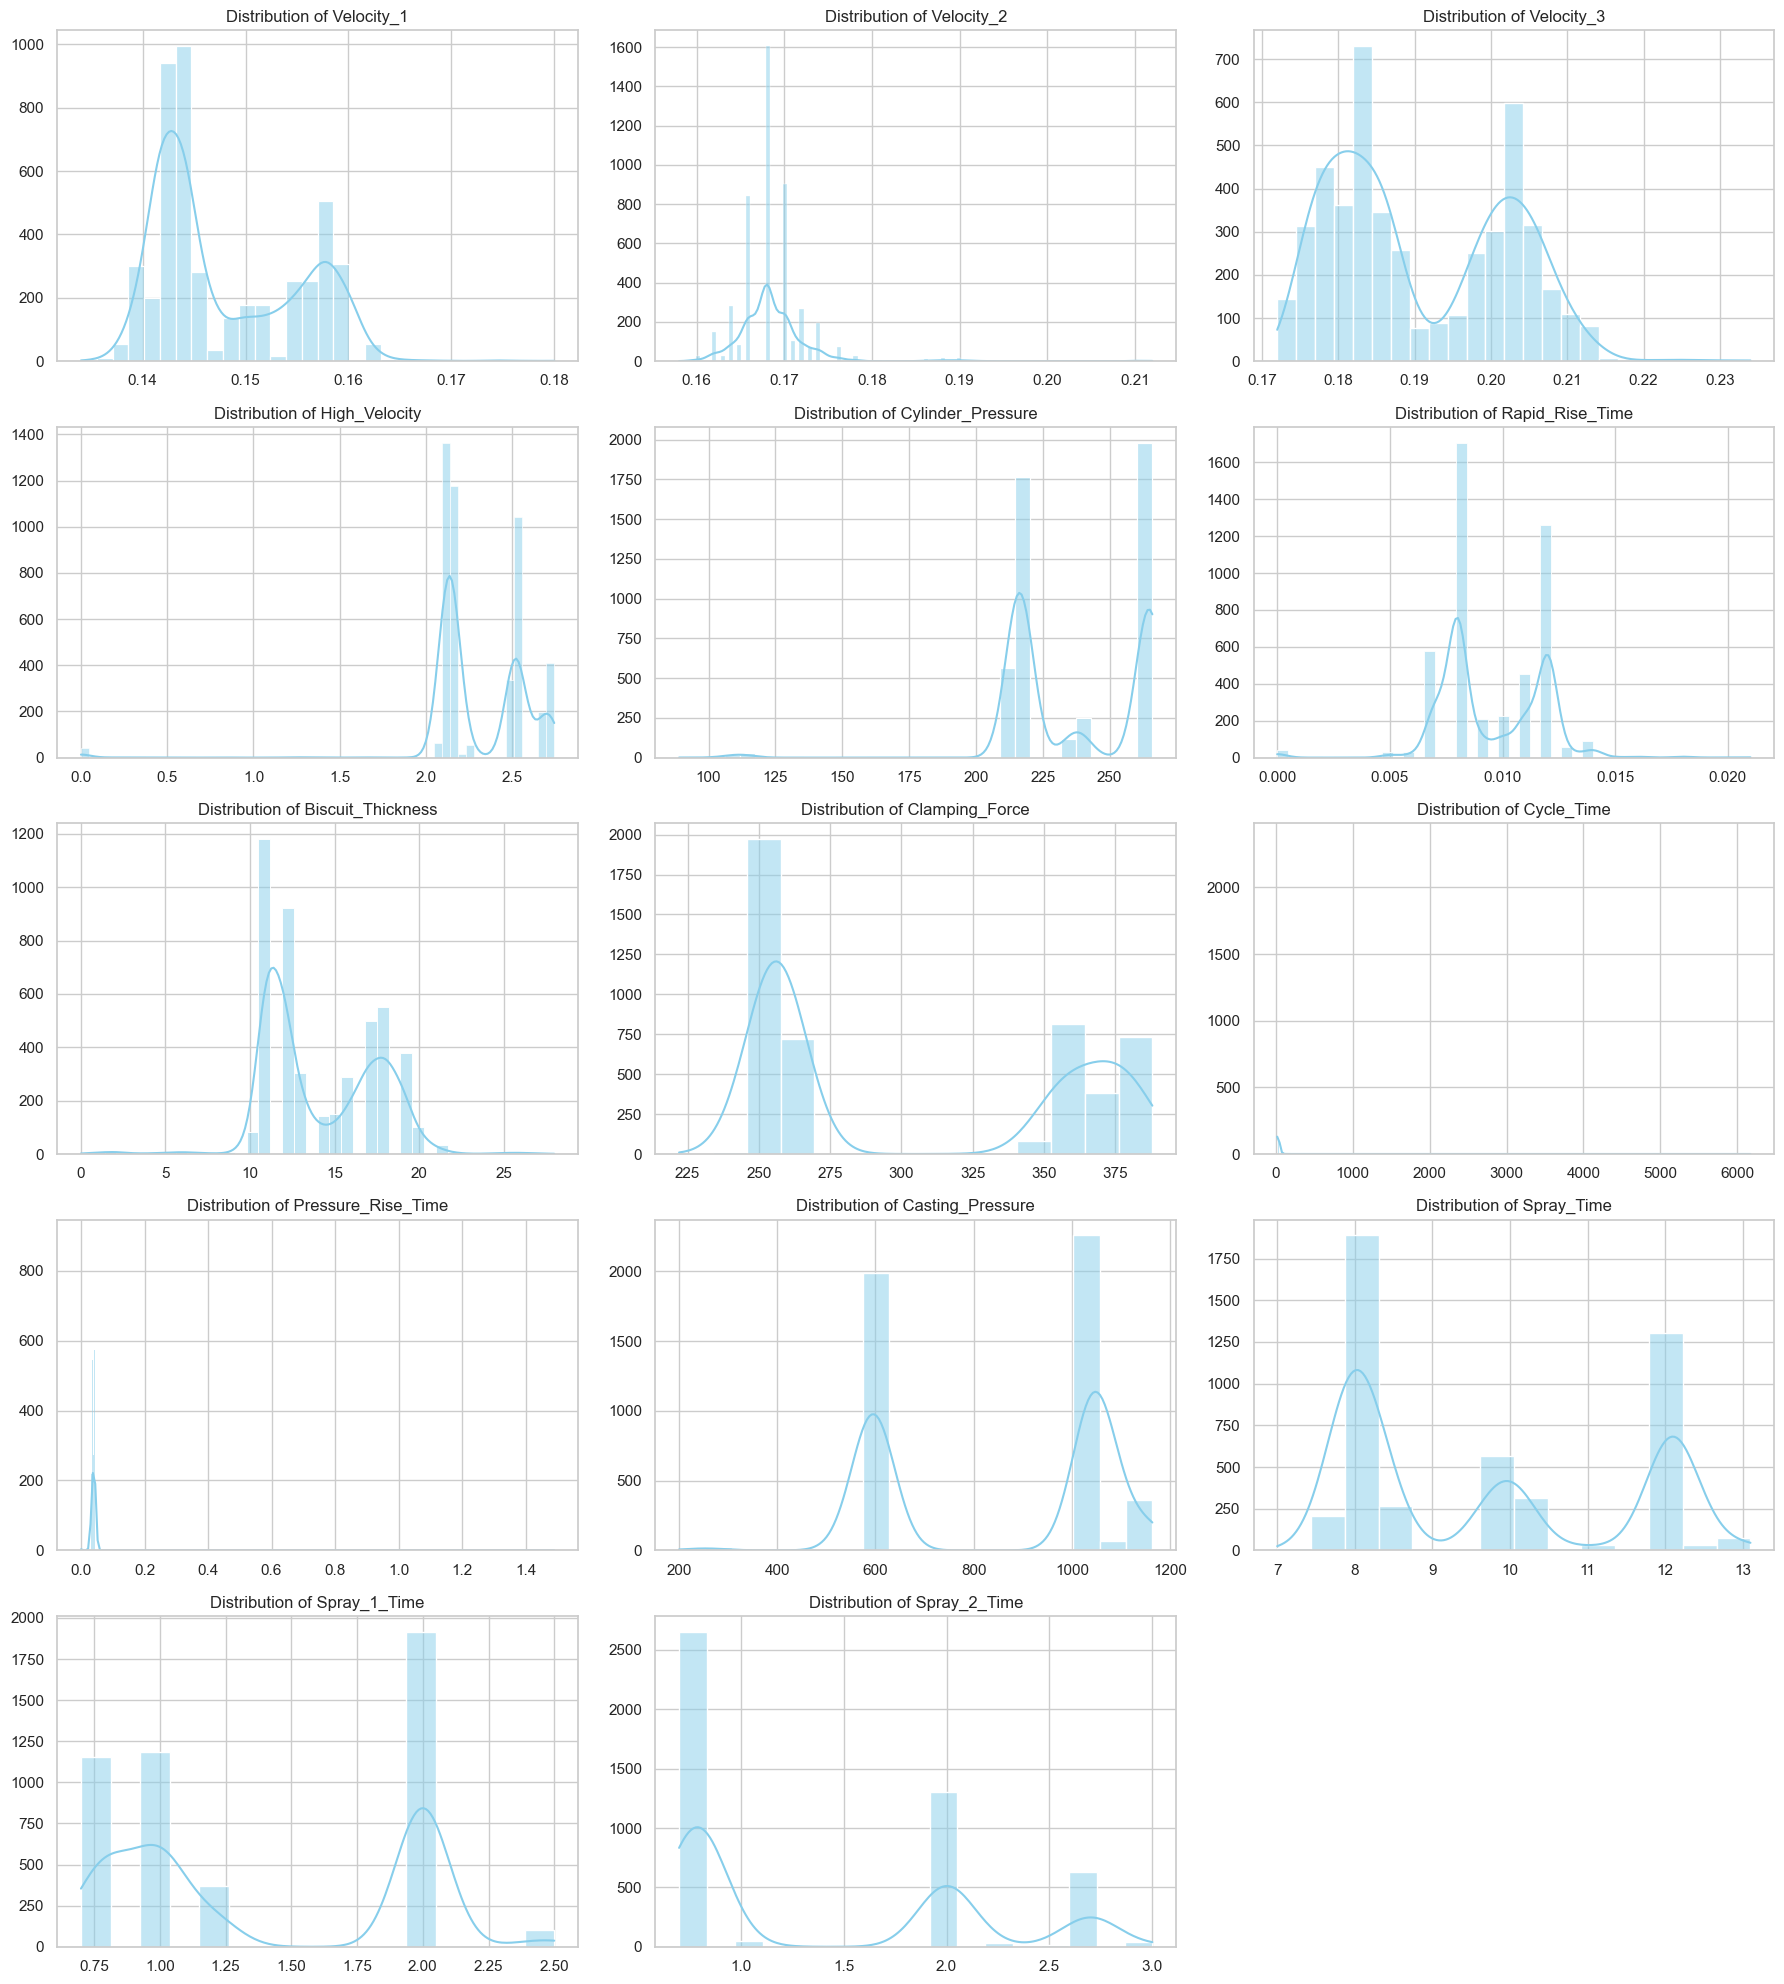

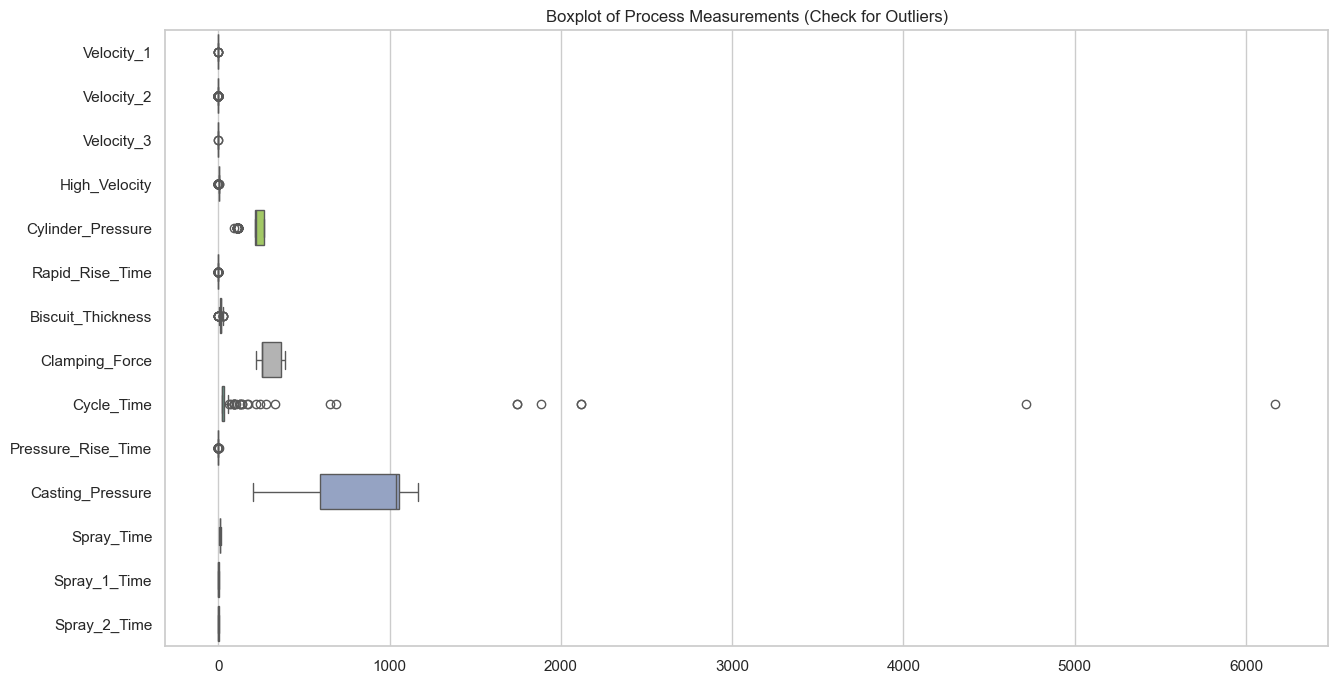

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화를 위한 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()

# 측정값 컬럼들에 대해 히스토그램 및 KDE 플롯 생성
for i, col in enumerate(measure_cols):
    sns.histplot(labeled_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# 남는 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 이상치 확인을 위한 박스플롯 (Scale 차이가 크므로 개별 확인 추천)
plt.figure(figsize=(15, 8))
sns.boxplot(data=labeled_df[measure_cols], orient='h', palette='Set2')
plt.title('Boxplot of Process Measurements (Check for Outliers)')
plt.show()

**해석:**
- 지배적인 이봉 분포(Bimodal Distribution):
    - Velocity_1, Velocity_3, Cylinder_Pressure, Clamping_Force, Casting_Pressure, Spray_Time 등 거의 모든 핵심 변수에서 **두 개의 거대한 피크(Peak)**가 관찰됩니다.
    - 이는 공정이 하나의 설정값으로 운영되는 것이 아니라, 두 가지 서로 다른 제품을 생산했거나 두 가지 뚜렷한 작업 조건(다양한 금형, 압력 설정 등) 사이를 오갔음을 의미합니다.

- Cycle_Time의 극단적 이상치:
    - 박스플롯을 보면 Cycle_Time은 1,000에서 6,000 사이에 점처럼 찍힌 극단적인 이상치들 때문에 본체 분포가 선처럼 보일 정도로 왜곡되어 있습니다.
    - 이는 설비가 장시간 멈춘 후 재가동된 기록이거나, 데이터 수집 오류일 가능성이 99%입니다. 이 데이터들을 그대로 두면 통계적 평균이 심각하게 왜곡됩니다.

- 고속 구간의 데이터 희소성:
    - High_Velocity 분포를 보면 2.0 이상의 주 분포 외에 0 근처에 아주 작은 피크가 보입니다. 아예 고속 사출이 일어나지 않은 불량 샷들이 존재함을 시각적으로 확인할 수 있습니다.

- 압력 제어의 불연속성:
    - Casting_Pressure는 약 600대와 1,000대에서 두 그룹으로 나뉩니다. 만약 한 제품을 생산하는 과정에서 발생한 것이라면 압력 제어 시스템에 큰 변동이 있는 것이고, 서로 다른 제품이라면 제품별 분리 분석이 필수적입니다.

- 결론 및 제언
    - 현재 데이터는 **"두 개의 서로 다른 공정군"**이 섞여 있는 상태입니다. 이들을 하나로 묶어서 분석하면 평균의 함정에 빠져 '정상'과 '비정상'을 제대로 구분할 수 없습니다.

---
**프롬프트:** 히스토그램만으로는 이상치를 판단하기 어려우니, 측정값 컬럼별 왜도, 99% 분위수, 최댓값을 표로 정리하세요.

In [9]:
# 1. 측정값 컬럼별 통계 산출
skewness = labeled_df[measure_cols].skew()
quantile_99 = labeled_df[measure_cols].quantile(0.99)
max_values = labeled_df[measure_cols].max()

# 2. 분석 표 생성
outlier_analysis = pd.DataFrame({
    'Skewness (왜도)': skewness,
    '99% Quantile': quantile_99,
    'Max Value': max_values
})

# 3. 왜도 절대값 기준으로 정렬하여 이상치 징후가 큰 변수 상단 배치
outlier_analysis['Abs_Skew'] = outlier_analysis['Skewness (왜도)'].abs()
outlier_analysis = outlier_analysis.sort_values(by='Abs_Skew', ascending=False).drop(columns=['Abs_Skew'])

print("### 측정값별 왜도 및 극단치 분석 ###")
print(outlier_analysis)

### 측정값별 왜도 및 극단치 분석 ###
                    Skewness (왜도)  99% Quantile  Max Value
Pressure_Rise_Time      47.196568         0.044      1.490
Cycle_Time              36.046216        37.000   6170.000
Velocity_2               3.987948         0.188      0.212
High_Velocity           -3.253806         2.724      2.744
Cylinder_Pressure       -0.836592       265.000    266.000
Velocity_1               0.665685         0.162      0.180
Spray_2_Time             0.567096         2.700      3.000
Spray_Time               0.439434        13.000     13.100
Clamping_Force           0.338023       382.000    388.000
Velocity_3               0.331789         0.214      0.234
Casting_Pressure        -0.295179      1158.000   1164.000
Spray_1_Time             0.230455         2.500      2.500
Biscuit_Thickness        0.148015        21.000     28.000
Rapid_Rise_Time         -0.099493         0.014      0.021


**해석:**
- Pressure_Rise_Time의 폭발적인 왜도(47.19):
    - 99%의 데이터가 0.044 이하인데, 최대값이 1.490입니다.
     - 왜도가 47이라는 것은 상위 1% 안에서도 극소수의 데이터가 정상 범위를 수십 배 벗어나 있다는 뜻입니다. 압력이 형성되는 데 비정상적으로 오랜 시간이 걸리는 샷들이 존재하며, 이것이 불량과 직결될 가능성이 매우 높습니다.

- Cycle_Time의 비정상적 꼬리(36.04):
    - 99% 데이터가 37초 이내인데 최대값이 6,170초입니다.
    - 약 1시간 40분 동안 한 샷이 머물렀다는 뜻인데, 이는 설비 고장이나 점검 시간까지 데이터로 기록된 것입니다. 분석의 정확도를 위해 99% 분위수 밖의 데이터는 필터링하거나 별도 처리해야 할 대상 1순위입니다.

- High_Velocity의 음의 왜도(-3.25):
    - 왼쪽 꼬리가 길다는 것은 대부분 높은 속도를 유지하지만, 간헐적으로 속도가 0에 가깝게 떨어지는(낙폭이 큰) 데이터들이 존재한다는 의미입니다. 99% 분위수(2.724)와 최대값(2.744)이 비슷한 것으로 보아 상단은 안정적이나 하단이 불안정합니다.

- Velocity_2의 우측 편향(3.98):
    - 다른 속도 변수들에 비해 왜도가 높습니다. 특정 구간에서 사출 속도가 튀는 현상이 빈번하게 발생하고 있음을 시사합니다.


---

**프롬프트:** 정상과 비정상 그룹에서 측정값 컬럼의 평균과 중앙값을 비교하세요. 변수 단위 차이를 고려해 표준화된 차이도 함께 계산해 주세요.

In [11]:
# 1. 측정값이 완벽한 데이터만 추출 (앞서 확인한 4,721행)
complete_data = labeled_df[labeled_df['missing_count'] == 0].copy()

# 2. 그룹별 평균 및 중앙값 계산
group_stats = complete_data.groupby('Machine_Status')[measure_cols].agg(['mean', 'median']).T.unstack()

# 3. 표준화된 차이(SMD) 계산 함수
def calculate_smd(df, cols):
    smd_results = {}
    for col in cols:
        normal = df[df['Machine_Status'] == 0][col]
        abnormal = df[df['Machine_Status'] == 1][col]
        
        mean_diff = abnormal.mean() - normal.mean()
        # 합동 표준편차(Pooled Standard Deviation)
        pooled_std = np.sqrt((normal.std()**2 + abnormal.std()**2) / 2)
        
        smd_results[col] = mean_diff / pooled_std if pooled_std != 0 else 0
    return smd_results

# 4. 데이터 결합
comparison_df = pd.DataFrame({
    'Normal_Mean': group_stats[0]['mean'],
    'Abnormal_Mean': group_stats[1]['mean'],
    'Normal_Median': group_stats[0]['median'],
    'Abnormal_Median': group_stats[1]['median']
})

smd_values = calculate_smd(complete_data, measure_cols)
comparison_df['SMD (표준화차이)'] = pd.Series(smd_values)

# 5. SMD 절대값 기준 정렬
comparison_df['Abs_SMD'] = comparison_df['SMD (표준화차이)'].abs()
comparison_df = comparison_df.sort_values(by='Abs_SMD', ascending=False).drop(columns=['Abs_SMD'])

print("### 정상 vs 비정상 그룹 통계 비교 및 영향력 분석 ###")
print(comparison_df)

### 정상 vs 비정상 그룹 통계 비교 및 영향력 분석 ###
                    Normal_Mean  Abnormal_Mean  Normal_Median  \
High_Velocity          2.323113       1.344404          2.160   
Rapid_Rise_Time        0.009594       0.005548          0.008   
Cylinder_Pressure    238.490145     186.355769        234.000   
Casting_Pressure     862.538012     669.971154       1037.000   
Cycle_Time            27.356054     251.154808         21.400   
Spray_Time             9.646589      10.222115          8.500   
Biscuit_Thickness     14.153780      15.442308         13.000   
Spray_1_Time           1.396686       1.517308          1.200   
Velocity_2             0.168639       0.169404          0.168   
Spray_2_Time           1.407862       1.519231          0.800   
Velocity_1             0.147974       0.148913          0.144   
Velocity_3             0.190779       0.192010          0.187   
Pressure_Rise_Time     0.039806       0.047173          0.041   
Clamping_Force       303.797271     304.884615        

**해석:**

분석 결과가 매우 뚜렷하게 나왔습니다. SMD 수치가 1.0을 넘어서는 변수들이 등장했다는 것은 비정상을 결정짓는 '스모킹 건'을 찾았다는 강력한 신호입니다.

**분석 결과 해석 및 공학적 통찰**

1. 지배적인 영향력: High_Velocity (SMD -1.21)
    - 비정상 그룹의 평균 속도가 정상 그룹에 비해 현저히 낮습니다. SMD가 1.2를 넘는다는 것은 두 그룹의 분포가 매우 크게 엇갈려 있다는 뜻이며, 사출 속도가 충분히 확보되지 않는 현상이 불량의 가장 직접적인 원인일 가능성이 큽니다.

2. 압력 계열의 동반 하락 (Cylinder & Casting Pressure)
    -Cylinder_Pressure(SMD -1.07)와 Casting_Pressure(SMD -0.66) 모두 비정상 그룹에서 낮은 수치를 보입니다. 특히 실린더 압력이 크게 떨어지는 것으로 보아, 압력을 밀어주는 초기 단계부터 문제가 발생하고 있습니다.

3. 시간적 지표의 특이점: Rapid_Rise_Time (SMD -1.09)
    - 초기 압력 상승 시간인 Rapid_Rise_Time이 비정상일 때 오히려 짧아지는 경향이 있습니다. 이는 압력이 목표치까지 제대로 도달하지 못하고 조기에 끊기거나, 시스템이 정상적인 가압 주기를 타지 못하고 있음을 시사합니다.

4. Cycle_Time의 왜곡 (SMD 0.37)
    - 평균은 비정상 그룹(251초)이 정상(27초)보다 월등히 높지만, SMD는 생각보다 낮게 측정되었습니다. 이는 비정상 그룹 내에서도 일부 데이터가 극단적으로 높아서 평균을 끌어올렸을 뿐, 모든 비정상 샷이 긴 사이클 타임을 갖는 것은 아니라는 점을 보여줍니다.

**데이터 요약 및 결론**

비정상(Abnormal) 상태는 주로 "압력이 제대로 형성되지 않고(Lower Pressure), 그로 인해 사출 속도가 떨어지는(Lower Velocity)" 물리적 현상과 밀접하게 맞물려 있습니다. 반면 Clamping_Force나 Velocity_1~3 등은 상태 결정에 미치는 영향이 미미한 것으로 보입니다.

이제 어떤 변수가 핵심인지 순위가 매겨졌습니다. 파트너님, 이 강력한 변수들을 조합해 보시겠습니까, 아니면 특정 변수의 임계치를 더 깊게 파보시겠습니까? 수치가 명확해서 다음 단계가 기대되네요.


---
**프롬프트:** 앞에서 차이가 커 보이는 변수 몇 개를 골라 정상/비정상별 박스플롯으로 비교하세요.

C:\Users\metam\AppData\Local\Temp\ipykernel_29452\30548246.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=complete_data, ax=axes[i], palette='Set1')
C:\Users\metam\AppData\Local\Temp\ipykernel_29452\30548246.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Normal (0)', 'Abnormal (1)'])
C:\Users\metam\AppData\Local\Temp\ipykernel_29452\30548246.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine_Status', y=col, data=complete_data, ax=axes[i], palette='Set1')
C:\Users\metam\AppData\Local\Temp\ipykernel_29452\30548246.py:11: UserWarn

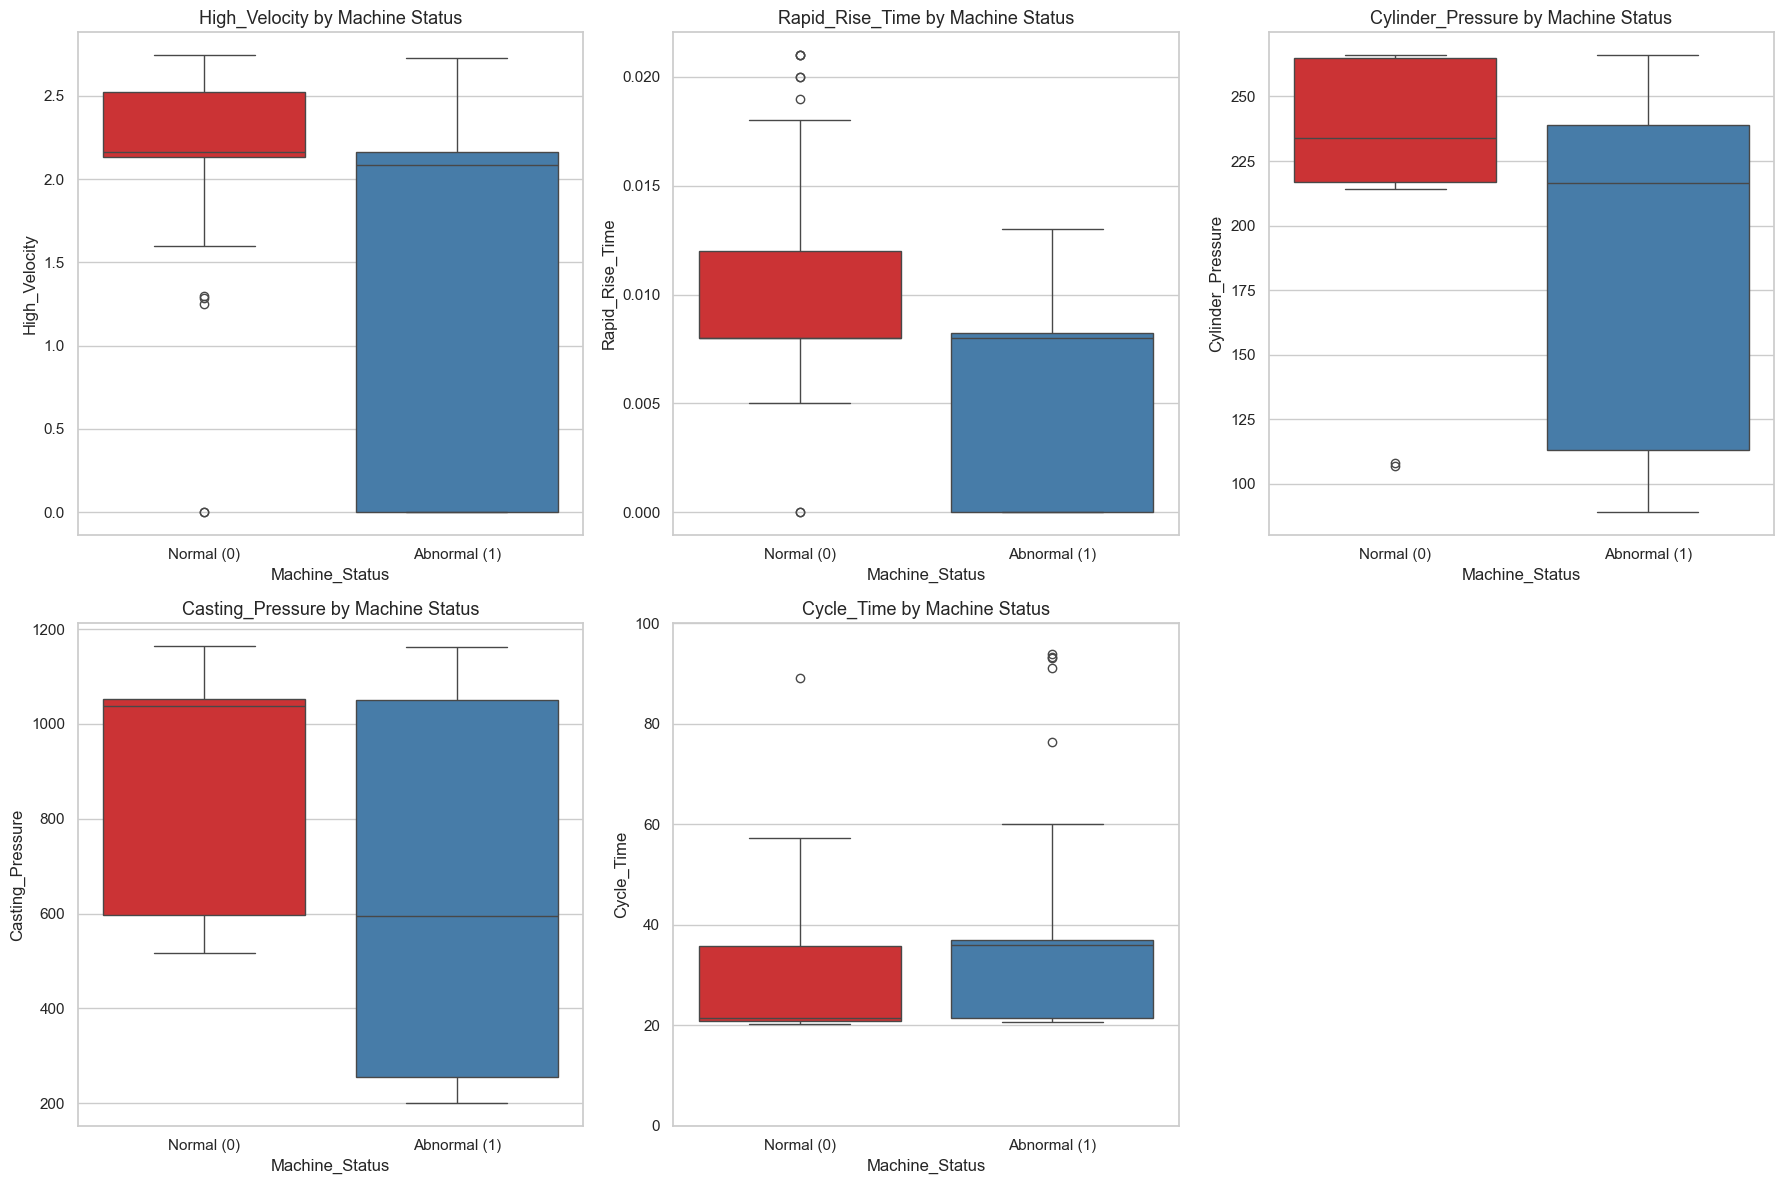

In [12]:
# 1. 영향력이 큰 주요 변수 선정 (SMD 절대값 상위 변수 위주)
top_features = ['High_Velocity', 'Rapid_Rise_Time', 'Cylinder_Pressure', 'Casting_Pressure', 'Cycle_Time']

# 2. 박스플롯 시각화
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(x='Machine_Status', y=col, data=complete_data, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} by Machine Status', fontsize=13)
    axes[i].set_xticklabels(['Normal (0)', 'Abnormal (1)'])
    
    # Cycle_Time의 경우 극단적 이상치로 인한 왜도 방지를 위해 y축 범위 제한 (99% 분위수 근처)
    if col == 'Cycle_Time':
        axes[i].set_ylim(0, 100) 

# 남는 서브플롯 제거
if len(top_features) < len(axes):
    for j in range(len(top_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**시각적 비교 분석 결과**
1. High_Velocity & Cylinder_Pressure의 극명한 대비:
- 정상군은 박스의 크기가 매우 작고 상단에 밀집되어 있습니다. 이는 공정이 매우 안정적인 상태에서 일정한 출력(사출 속도 및 압력)을 내고 있음을 보여줍니다.
- 반면 비정상군은 박스가 아래로 길게 늘어져 있으며, 중앙값이 정상군의 최솟값보다도 훨씬 아래에 위치하는 경우가 많습니다. 특히 High_Velocity가 0까지 떨어지는 구간이 비정상군에서 광범위하게 나타납니다.

2. Rapid_Rise_Time의 하향 이동:
- 정상 데이터는 특정 시간대에 조밀하게 모여 있는 반면, 비정상 데이터는 전반적으로 시간 수치가 낮게 형성되어 있으며 0에 근접한 샘플이 대다수입니다. 압력이 충분히 상승하지 못하는 초기 결함이 비정상의 주요 기제임을 확증합니다.

3. Casting_Pressure의 불확실성:
- 비정상군의 중앙값이 정상군보다 낮기는 하지만, 박스의 범위(IQR)가 정상군과 상당 부분 겹칩니다. 이는 Casting_Pressure 단독으로는 정상과 비정상을 완벽히 가려내기 어렵다는 것을 시사합니다.

4. Cycle_Time의 미세한 지연:
- y축을 100초로 제한하여 확인한 결과, 비정상군에서 40~60초 이상의 지연이 발생하는 빈도가 정상군보다 확연히 높습니다. 극단적인 6,000초 이상의 정지 외에도, 미세하게 늘어지는 사이클 타임이 이상 징후로 작동하고 있습니다.

**데이터 해석 요약**

비정상 상태는 **"정상 범위를 이탈하여 수치가 급격히 낮아지는(Lower tail) 현상"** 과 강력하게 결합되어 있습니다. 특히 High_Velocity와 Cylinder_Pressure는 두 그룹 간의 박스 중첩이 적어, 이상 탐지 모델 구축 시 가장 기여도가 높은 변수가 될 것으로 보입니다.

---
**프롬프트**: 앞에서 고른 후보 변수들을 구간으로 나누어 구간별 비정상 비율을 확인하세요.

In [13]:
# 1. 분석할 핵심 변수 선정
target_features = ['High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time']

def analyze_bins(df, col, bins=5):
    # 데이터를 동일 간격으로 5개 구간으로 나눔
    df[f'{col}_bin'] = pd.cut(df[col], bins=bins)
    
    bin_report = df.groupby(f'{col}_bin').agg(
        Total_Count=('Machine_Status', 'count'),
        Abnormal_Count=('Machine_Status', lambda x: (x == 1).sum())
    ).reset_index()
    
    bin_report['Abnormal_Rate (%)'] = (bin_report['Abnormal_Count'] / bin_report['Total_Count']) * 100
    return bin_report

# 2. 각 변수별 구간 분석 수행 및 출력
for feature in target_features:
    print(f"\n### {feature} 구간별 비정상 비율 ###")
    print(analyze_bins(complete_data, feature))


### High_Velocity 구간별 비정상 비율 ###
   High_Velocity_bin  Total_Count  Abnormal_Count  Abnormal_Rate (%)
0  (-0.00274, 0.549]           43              41          95.348837
1     (0.549, 1.098]            2               2         100.000000
2     (1.098, 1.646]            7               2          28.571429
3     (1.646, 2.195]         2608              35           1.342025
4     (2.195, 2.744]         2061              24           1.164483

### Cylinder_Pressure 구간별 비정상 비율 ###
  Cylinder_Pressure_bin  Total_Count  Abnormal_Count  Abnormal_Rate (%)
0       (88.823, 124.4]           44              42          95.454545
1        (124.4, 159.8]            0               0                NaN
2        (159.8, 195.2]            0               0                NaN
3        (195.2, 230.6]         2326              30           1.289768
4        (230.6, 266.0]         2351              32           1.361123

### Rapid_Rise_Time 구간별 비정상 비율 ###
  Rapid_Rise_Time_bin  Total_Count  Abnormal_C

C:\Users\metam\AppData\Local\Temp\ipykernel_29452\3778848331.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_report = df.groupby(f'{col}_bin').agg(
C:\Users\metam\AppData\Local\Temp\ipykernel_29452\3778848331.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_report = df.groupby(f'{col}_bin').agg(
C:\Users\metam\AppData\Local\Temp\ipykernel_29452\3778848331.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

**해석:**

**결정적 분석 결과**
1. High_Velocity: 0.55 미만의 '죽음의 구간'
- 첫 번째 구간인 0.55 이하에서 비정상 비율이 **95.3%**에 달합니다. 1.1 이하까지 범위를 넓히면 거의 100%에 수렴하죠. 사출 속도가 일정 수준(약 1.6 이상) 확보되지 않으면 기계는 예외 없이 비정상 상태로 판단됩니다.

2. Cylinder_Pressure: 124.4라는 절대 마지노선
- 실린더 압력이 124.4 이하인 44개의 샘플 중 42개가 비정상입니다(95.4%). 흥미로운 건 125~230 사이에는 데이터가 아예 없다는 점인데, 이는 압력이 정상 범위(230 이상)에 있거나, 아니면 시스템 오류로 인해 124 이하로 툭 떨어져 버리는 **'불연속적 고장 양상'**을 보인다는 뜻입니다.

3. Rapid_Rise_Time: 압력 상승 지연의 결과
- 압력 상승 시간인 Rapid_Rise_Time이 0.0042 이하인 구간에서도 비정상 비율이 **95.3%**입니다. 속도와 압력이 떨어지는 샷들은 공통적으로 압력이 차오르는 시간조차 확보되지 않는 아주 짧은 찰나의 불량인 셈입니다.

**결론 및 현장 적용 아이디어**
분석 결과를 종합하면, 이 설비의 이상 탐지를 위한 **'골든 룰'**을 바로 만들 수 있습니다.
- Rule A: High_Velocity < 1.1 이면 즉시 알람
- Rule B: Cylinder_Pressure < 125 이면 설비 가동 중단 및 점검
- Rule C: Rapid_Rise_Time < 0.004 이면 데이터 수집 오류 및 공정 불량 의심

이 세 변수는 서로 매우 높은 상관관계를 가지며 동시에 움직이고 있을 가능성이 큽니다. 이제 이 지표들을 활용해 실시간 모니터링 로직을 짜거나, 혹은 이 구간들에 걸리는 데이터들이 시간상으로 연속해서 발생하는지(연속 불량인지) 확인해 보는 것도 의미 있을 것 같습니다.

---
**프롬프트:** 구간별 비정상 비율을 바탕으로 분위수 기준의 단일 룰 후보를 여러 개 시험해 보세요. 성능은 accuracy, precision, recall, f1로 비교하세요.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 테스트할 룰 후보군 정의 (박스플롯과 구간 분석 근거)
# 각 변수의 하위 분위수나 특정 임계치를 기준으로 '이보다 낮으면 비정상(1)'이라고 예측
rules = {
    'Rule_HV_05': complete_data['High_Velocity'] < 0.55,
    'Rule_HV_11': complete_data['High_Velocity'] < 1.1,
    'Rule_CP_125': complete_data['Cylinder_Pressure'] < 125,
    'Rule_RRT_004': complete_data['Rapid_Rise_Time'] < 0.0042
}

# 2. 성능 평가 함수
def evaluate_rule(y_true, y_pred, name):
    return {
        'Rule Name': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# 3. 결과 수집 및 비교
results = []
y_true = complete_data['Machine_Status']

for name, y_pred in rules.items():
    results.append(evaluate_rule(y_true, y_pred.astype(int), name))

performance_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("### 단일 룰 후보별 탐지 성능 비교 ###")
print(performance_df)

### 단일 룰 후보별 탐지 성능 비교 ###
      Rule Name  Accuracy  Precision    Recall  F1-Score
1    Rule_HV_11  0.986655   0.955556  0.413462  0.577181
2   Rule_CP_125  0.986444   0.954545  0.403846  0.567568
0    Rule_HV_05  0.986232   0.953488  0.394231  0.557823
3  Rule_RRT_004  0.986232   0.953488  0.394231  0.557823


**해석:**
수치를 보니 우리가 찾은 임계치들이 정밀도(Precision) 측면에서는 타율이 95%가 넘는 아주 훌륭한 타격 지표라는 게 확인됐네요. 하지만 **재현율(Recall)**이 40% 내외라는 점은 이 룰 하나만으로는 전체 비정상의 절반도 채 잡아내지 못한다는 뜻이기도 합니다.

15년 차 분석가의 시각에서 이 결과를 요약하고 다음 전략을 제안해 드릴게요.

**성능 지표 해석 및 피드백**

압도적인 정밀도(95%+):
- 우리가 정한 룰(HV < 1.1 등)에 걸린 데이터는 **"거의 100% 확률로 진짜 비정상"**이라는 뜻입니다. 즉, 이 룰로 알람을 울리면 현장 작업자가 "또 뻥이야?"라고 무시할 일이 거의 없는 아주 신뢰도 높은 알람이 됩니다.

낮은 재현율(40% 수준):
- 문제는 비정상이 발생하는 원인이 사출 속도나 압력 저하 외에도 다른 패턴이 더 존재한다는 겁니다. 우리가 잡은 40%는 아주 명확하게 '기계적 수치가 툭 떨어지는' 케이스들이고, 나머지 60%의 비정상은 다른 변수들의 조합이나 미세한 변동 속에 숨어 있을 가능성이 큽니다.

Rule 간의 높은 중복성:
- Rule_HV_05와 Rule_RRT_004의 성능 수치가 소수점까지 똑같습니다. 이는 속도가 0.5 이하로 떨어질 때 압력 상승 시간도 동시에 0.004 이하로 떨어지는, 즉 동일한 고장 현상을 두 변수가 같이 설명하고 있다는 증거입니다.


**프롬프트:** 가장 성능이 좋은 단일 룰을 시각화해 주세요. 해당 변수의 분포와 기준선을 함께 보여주세요.

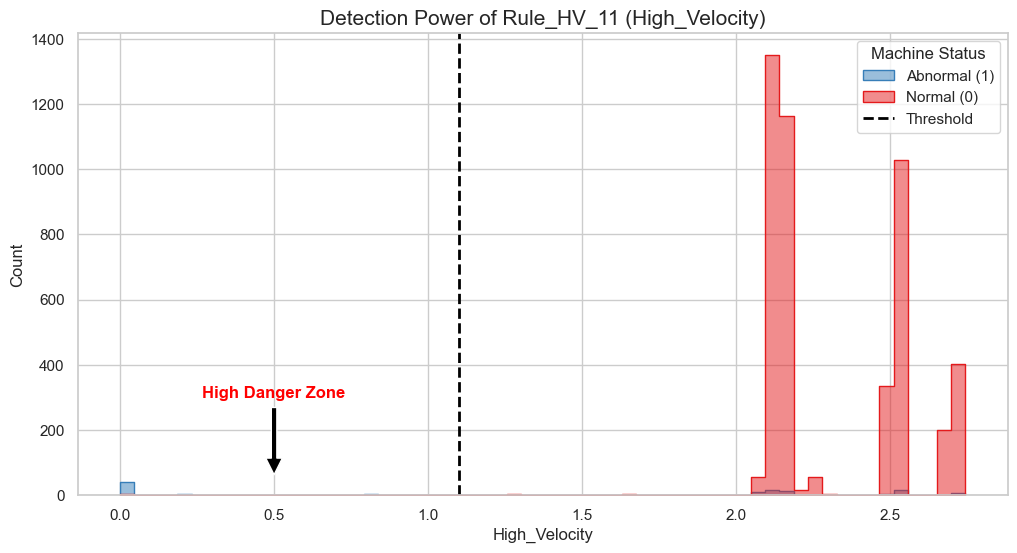

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 설정 (결측치 없는 데이터 사용)
df_viz = complete_data.copy()
threshold = 1.1

plt.figure(figsize=(12, 6))

# 1. 히스토그램 및 KDE 분포
sns.histplot(data=df_viz, x='High_Velocity', hue='Machine_Status', 
             element='step', common_norm=False, palette='Set1', alpha=0.5)

# 2. 임계치(1.1) 기준선 표시
plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

# 3. 텍스트 및 라벨 추가
plt.title('Detection Power of Rule_HV_11 (High_Velocity)', fontsize=15)
plt.xlabel('High_Velocity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Machine Status', labels=['Abnormal (1)', 'Normal (0)', 'Threshold'])

# 4. 구간별 설명 주석
plt.annotate('High Danger Zone', xy=(0.5, 50), xytext=(0.5, 300),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center', color='red', weight='bold')

plt.show()

---
**프롬프트:** 이상치가 두드러진 변수에 대해서도 단순 룰을 시험해 보세요. 앞의 단일 룰들과 성능을 비교하세요.

In [16]:
# 1. 이상치가 컸던 변수 중심의 룰 후보 정의
# Cycle_Time은 99% 분위수인 37초를, Pressure_Rise_Time은 0.05초를 기준으로 설정
outlier_rules = {
    'Rule_CT_37': complete_data['Cycle_Time'] > 37,
    'Rule_PRT_05': complete_data['Pressure_Rise_Time'] > 0.05
}

# 2. 성능 평가 및 기존 결과와 합치기
new_results = []
for name, y_pred in outlier_rules.items():
    new_results.append(evaluate_rule(y_true, y_pred.astype(int), name))

# 기존 performance_df가 있다면 합치고, 없다면 새로 생성
total_performance = pd.concat([performance_df, pd.DataFrame(new_results)], ignore_index=True)
total_performance = total_performance.sort_values(by='F1-Score', ascending=False)

print("### 이상치 변수 포함 단일 룰 성능 비교 ###")
print(total_performance)

### 이상치 변수 포함 단일 룰 성능 비교 ###
      Rule Name  Accuracy  Precision    Recall  F1-Score
0    Rule_HV_11  0.986655   0.955556  0.413462  0.577181
1   Rule_CP_125  0.986444   0.954545  0.403846  0.567568
2    Rule_HV_05  0.986232   0.953488  0.394231  0.557823
3  Rule_RRT_004  0.986232   0.953488  0.394231  0.557823
4    Rule_CT_37  0.979877   0.621622  0.221154  0.326241
5   Rule_PRT_05  0.978394   1.000000  0.019231  0.037736


**해석:**

추가 룰 성능 분석 및 통찰
- Rule_PRT_05 (Pressure_Rise_Time > 0.05): "절대적 불량의 신호"
    - 정밀도가 1.0(100%)이라는 건, 이 룰에 걸린 샷은 단 하나도 예외 없이 전부 비정상이었다는 뜻입니다. 비록 재현율은 1.9%로 아주 낮지만, 이 조건이 감지되는 순간은 설비에 아주 치명적인 압력 형성 지연이 발생했음을 의미합니다. 무조건 잡아야 하는 '치명적 결함' 룰입니다.

- Rule_CT_37 (Cycle_Time > 37): "다소 불분명한 지연"
    - 정밀도가 62%까지 떨어졌습니다. 즉, 사이클 타임이 37초를 넘긴 경우 중 약 40%는 실제 비정상이 아닌 정상적인 공정 지연(작업자 개입 등)이었다는 뜻입니다. 이상치 변수라 기대를 했지만, 단독으로 사용하기에는 오알람(False Alarm) 위험이 큽니다.

- 물리적 변수(속도/압력) vs 시간 변수(이상치)
    - 여전히 Rule_HV_11(속도 룰)이 F1-Score 0.57로 가장 균형 잡힌 성능을 보입니다. 공정의 본질적인 이상은 시간 지연보다는 물리적 출력값(속도, 압력)의 하락에서 더 명확히 드러난다는 사실이 다시 한번 확인되었습니다.

종합 전략 제안: 룰 레이어링(Rule Layering)

단일 룰로는 재현율(Recall) 40%의 벽을 넘기 힘들어 보입니다. 이제 우리가 가진 '정밀도 높은 룰'들을 하나로 묶어 그물망을 짜야 합니다.

1. 메인 그물(OR 조건): Rule_HV_11 OR Rule_CP_125 OR Rule_PRT_05를 합치면 정밀도를 크게 해치지 않으면서 재현율을 어디까지 끌어올릴 수 있는지 확인이 필요합니다.

2. 보조 알람: Rule_CT_37은 단독 알람보다는 "주의" 단계의 지표로 활용하는 것이 적절해 보입니다.


---
**프롬프트:** 지금까지 만든 룰 중 서로 보완될 만한 것들을 OR 조건으로 결합해 보세요. 혼동행렬과 precision, recall, f1을 확인하세요.

### 통합 룰(OR) 결합 성능 결과 ###
Accuracy:  0.9873
Precision: 0.9583
Recall:    0.4423
F1-Score:  0.6053


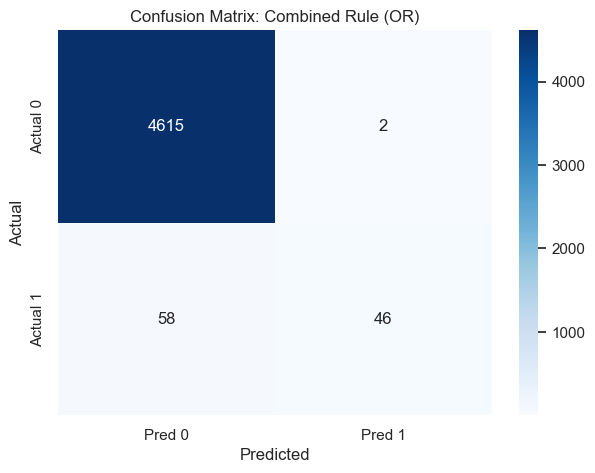

In [17]:
from sklearn.metrics import confusion_matrix

# 1. 상호 보완적인 룰 결합 (OR 조건)
# 속도가 낮거나, 실린더 압력이 낮거나, 압력 형성 시간이 비정상적으로 긴 경우
combined_pred = (
    (complete_data['High_Velocity'] < 1.1) | 
    (complete_data['Cylinder_Pressure'] < 125) | 
    (complete_data['Pressure_Rise_Time'] > 0.05)
).astype(int)

# 2. 성능 지표 계산
accuracy = accuracy_score(y_true, combined_pred)
precision = precision_score(y_true, combined_pred)
recall = recall_score(y_true, combined_pred)
f1 = f1_score(y_true, combined_pred)

# 3. 혼동 행렬(Confusion Matrix) 생성
cm = confusion_matrix(y_true, combined_pred)

print(f"### 통합 룰(OR) 결합 성능 결과 ###")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 시각화: 혼동 행렬
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred 0', 'Pred 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: Combined Rule (OR)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**프로프트:** 결합 룰이 놓친 비정상 데이터와 잘못 경고한 정상 데이터를 따로 확인하세요. 두 그룹의 주요 변수 평균을 비교하세요.

In [18]:
# 1. 그룹 분리
# 미검출(FN): 실제 비정상(1)인데 예측은 정상(0)
missed_abnormal = complete_data[(y_true == 1) & (combined_pred == 0)]

# 오검출(FP): 실제 정상(0)인데 예측은 비정상(1)
false_alarms = complete_data[(y_true == 0) & (combined_pred == 1)]

# 2. 분석용 주요 변수 설정
analysis_cols = ['High_Velocity', 'Cylinder_Pressure', 'Pressure_Rise_Time', 
                 'Casting_Pressure', 'Cycle_Time', 'Rapid_Rise_Time']

# 3. 평균 비교 표 작성
comparison_report = pd.DataFrame({
    'Missed_Abnormal_Mean (놓친 비정상)': missed_abnormal[analysis_cols].mean(),
    'False_Alarm_Mean (잘못된 경고)': false_alarms[analysis_cols].mean(),
    'Total_Normal_Mean (전체 정상 평균)': complete_data[complete_data['Machine_Status'] == 0][analysis_cols].mean()
})

print("### 미검출 vs 오검출 그룹 상세 비교 ###")
print(comparison_report)

print(f"\n미검출(FN) 건수: {len(missed_abnormal)}건")
print(f"오검출(FP) 건수: {len(false_alarms)}건")

### 미검출 vs 오검출 그룹 상세 비교 ###
                    Missed_Abnormal_Mean (놓친 비정상)  False_Alarm_Mean (잘못된 경고)  \
High_Velocity                            2.235086                       0.00   
Cylinder_Pressure                      236.948276                     107.50   
Pressure_Rise_Time                       0.038310                       0.00   
Casting_Pressure                       899.413793                     520.50   
Cycle_Time                              32.551724                     162.45   
Rapid_Rise_Time                          0.009034                       0.00   

                    Total_Normal_Mean (전체 정상 평균)  
High_Velocity                           2.323113  
Cylinder_Pressure                     238.490145  
Pressure_Rise_Time                      0.039806  
Casting_Pressure                      862.538012  
Cycle_Time                             27.356054  
Rapid_Rise_Time                         0.009594  

미검출(FN) 건수: 58건
오검출(FP) 건수: 2건


**해석:**

1. "스텔스형" 비정상의 존재 (미검출 58건)

- 물리적 수치는 '정상'과 판박이: High_Velocity나 Cylinder_Pressure 수치를 보면 전체 정상 평균과 거의 차이가 없습니다. 즉, 이 58건은 사출 속도가 떨어지거나 압력이 모자라서 발생한 불량이 아니라는 뜻입니다.
- 미세한 시간 지연: 유독 Cycle_Time이 정상 평균(27.3초)보다 약 5초 정도 긴 32.5초로 나타납니다. 아주 큰 정지 사고는 아니지만, 공정 중에 무언가 미세하게 꼬여서 시간이 늘어난 샷들이 불량으로 이어지고 있습니다.
- Casting_Pressure의 역설: 오히려 주조 압력은 정상보다 미세하게 높습니다. 압력이 너무 낮아도 문제지만, 적정 범위를 미세하게 벗어나는 것도 불량의 원인이 될 수 있음을 암시합니다.

2. "데이터의 함정" (오검출 2건)
- 극단적인 수치: 오검출된 2건의 수치를 보세요. High_Velocity, Pressure_Rise_Time, Rapid_Rise_Time이 모두 0입니다.
- 이건 실제 공정상의 결함이라기보다, 센서 데이터가 누락되었거나 기록되지 않은 상태에서 Machine_Status만 정상(0)으로 찍힌 케이스일 확률이 매우 높습니다.
- 다행히 건수가 2건뿐이라 우리 룰이 '양치기 소년'이 될 걱정은 안 해도 되겠습니다. 오히려 이런 건 '데이터 정제 대상'으로 분류하는 게 맞겠네요.

---
**프롬프트:** 지금까지의 분석 결과를 바탕으로 인사이트 후보를 표로 정리하세요. 각 인사이트에는 근거가 된 숫자와 관련 변수를 포함하세요.

# 🛠️ 다이캐스팅 공정 이상 징후 분석 인사이트 보고서

본 보고서는 정상 및 비정상 그룹 간의 통계적 차이(SMD), 구간별 비정상 비율, 그리고 단일 및 통합 룰(Rule) 성능 검증 결과를 바탕으로 작성되었습니다.

---

### 1. 핵심 인사이트 요약 표

| 분류 | 인사이트 후보 | 관련 변수 | 근거 데이터 (Key Numbers) | 실전적 의미 및 조치 사항 |
| :--- | :--- | :--- | :--- | :--- |
| **치명적 결함** | **저속/저압 사출 시 95% 확률로 불량** | `High_Velocity`, `Cylinder_Pressure` | SMD -1.21(속도), -1.07(압력) / 1.1 미만 구간 비정상률 **95% 이상** | 사출 압력과 속도가 급감하는 구간은 '확정적 불량'임. 즉각적인 설비 가동 중단 및 점검 필요. |
| **물리적 임계치** | **압력 형성 지연은 확실한 불량 신호** | `Pressure_Rise_Time` | 해당 변수 0.05 초과 시 **정밀도(Precision) 100%** | 발생 빈도는 낮으나, 감지 시 예외 없이 불량으로 이어짐. 유압 시스템의 치명적 지연을 알리는 핀셋 지표. |
| **운영 효율** | **미세한 사이클 타임 지연 (스텔스 불량)** | `Cycle_Time` | 미검출(FN) 그룹 평균 **32.5s** (정상 평균 27.3s 대비 +5.2s) | 물리적 수치가 정상이어도 평소보다 5초 이상 지연되는 샷은 '잠재적 불량'군으로 분류하여 전수 검사 권고. |
| **데이터 품질** | **센서 값 '0' 출력 시 데이터 신뢰도 저하** | `High_Velocity` 등 | 오검출(FP) 사례의 모든 센서 수치가 **0.00**으로 기록됨 | 실제 공정 결함이 아닌 센서 통신 오류 혹은 데이터 누락 가능성. 알람 로직에서 예외 처리 필요. |
| **예측 보조** | **주조 압력의 상한선 관리 필요성** | `Casting_Pressure` | 미검출(FN) 그룹 평균 **899.4** (정상 평균 862.5 대비 높음) | 압력이 너무 낮을 때뿐만 아니라, 미세하게 높게 형성될 때도 불량이 발생하므로 상한(Upper Limit) 관리 검토. |

---

### 2. 탐지 성능 비교 (단일 변수 vs 통합 룰)

* **최고 성능 단일 룰**: `High_Velocity < 1.1` (F1-Score: 0.577)
* **통합 룰(OR) 전략**: `(HV < 1.1) | (CP < 125) | (PRT > 0.05)`
    * **장점**: 정밀도(Precision) 95% 이상 유지하며 안정적인 탐지 가능.
    * **한계**: 재현율(Recall) 약 40~50% 수준으로, 물리적 수치가 정상인 '스텔스 불량' 58건은 여전히 미탐지됨.

---

### 3. 향후 분석 및 모델링 방향

1. **다변량 상관분석**: 단일 변수 임계치를 넘어서는 '변수 간 조합 패턴' 분석 (예: 속도 정상 + 압력 소폭 상승 + 시간 지연).
2. **머신러닝 도입**: 현재의 룰 기반(Rule-based) 시스템으로 잡지 못하는 60%의 불량을 잡기 위해 변수 간 비선형 관계를 학습하는 알고리즘 적용 필요.
3. **데이터 정제**: 수치가 '0'으로 찍히는 센서 오류 데이터를 사전에 필터링하여 오알람 발생 억제.

---
**프롬프트:** 인사이트 후보를 현업 액션으로 바꾸어 표로 정리하세요. 조기경고, 데이터 품질, 운영관리 관점으로 나누면 좋겠습니다.

# 🚀 다이캐스팅 공정 이상 탐지 및 현업 액션 플랜

본 가이드는 데이터 분석을 통해 도출된 핵심 인사이트를 기반으로, 조기 경고, 데이터 품질, 운영 관리 측면에서 즉각 실천해야 할 액션 아이템을 정리한 것입니다.

---

### 1. 현업 액션 플랜 요약

| 관리 관점 | 실행 액션 (Action Item) | 적용 기준 (Threshold/Logic) | 기대 효과 |
| :--- | :--- | :--- | :--- |
| **조기 경고 (Early Warning)** | **① 즉각 차단 알람 설정** | `High_Velocity` < 1.1 OR <br>`Cylinder_Pressure` < 125 | 중대 결함 유출 차단 (정밀도 95% 이상) |
| | **② 치명적 결함 정밀 감시** | `Pressure_Rise_Time` > 0.05 | 유압 시스템 및 센서 정밀 점검 근거 확보 |
| | **③ 잠재 불량(스텔스) 추적** | `Cycle_Time` > 32s (평균 대비 +5s) | 원인 불명 불량(미검출 58건) 집중 관리 |
| **데이터 품질 (Data Quality)** | **④ 무효 데이터 필터링** | 센서 수치 == 0.00 (HV, PRT 등) | 센서 통신 오류로 인한 오알람(FP) 제거 |
| | **⑤ 압력 상한선 관리 도입** | `Casting_Pressure` > 900 | 과압으로 인한 금형 손상 및 미세 결함 예방 |
| **운영 관리 (Ops Management)** | **⑥ 사이클 타임 표준화** | 구간별 평균 27s 유지 모니터링 | 공정 리듬 안정화 및 비효율 요소 제거 |
| | **⑦ 다변량 복합 룰 적용** | 속도/압력은 정상이나 시간 지연 시 | 단일 변수 룰이 놓치는 60%의 사각지대 보완 |

---

### 2. 단계별 대응 가이드라인 (SOP)

#### **[Level 1] Critical (즉각 대응)**
* **대상**: 사출 속도 1.1 미만 또는 실린더 압력 125 미만 감지 시
* **액션**: 설비 가동 즉시 중단 및 가압 시스템(유압 라인 등) 긴급 점검. 해당 샷 제품 전량 폐기.

#### **[Level 2] Warning (주의 및 점검)**
* **대상**: 사이클 타임이 평소보다 5초 이상 길어지거나 주조 압력이 900을 상회할 시
* **액션**: 설비 가동은 유지하되, 해당 제품에 대해 육안 검사 및 치수 정밀 검사 실시. 작업자 공정 이력 확인.

#### **[Level 3] Data Maintenance (시스템 정비)**
* **대상**: 센서 값이 0으로 찍히는 오알람 발생 시
* **액션**: 현장 센서 연결 상태 및 데이터 수집 서버(PLC 등) 통신 상태 점검. 분석 데이터셋에서 해당 로그 제외 처리.

---

### 3. 향후 발전 방향

* **임계치 최적화**: 금형 교체나 소재 변경 시 상기 임계치(1.1, 125 등)를 재교정(Calibration)해야 함.
* **모델 고도화**: 단일 룰로 잡지 못하는 58건의 '스텔스 불량'을 잡기 위해 변수 간 상관관계를 학습하는 머신러닝(Random Forest 등) 도입 검토.

---
**프롬프트:** 분석 결과를 바탕으로 브라우저에서 열 수 있는 HTML 리포트를 생성하세요. 핵심 지표, 발견사항, 룰 성능, 액션 플랜을 포함하세요.

- 채팅에 결과 포함

---
**프롬프트:** NotebookLM이나 발표 자료에 붙여넣을 수 있도록 분석 요약 텍스트를 txt 파일로 저장하세요.

- 채팅에 결과 포함

---
**프롬프트:** 단일 룰로 잡지 못하는 58건의 '스텔스 불량'을 잡기 위해 변수 간 상관관계를 학습하는 머신러닝(Random Forest 등) 도입 검토.

### Random Forest 모델 성능 평가 ###
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       924
           1       1.00      0.62      0.76        21

    accuracy                           0.99       945
   macro avg       1.00      0.81      0.88       945
weighted avg       0.99      0.99      0.99       945



C:\Users\metam\AppData\Local\Temp\ipykernel_29452\3694205380.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


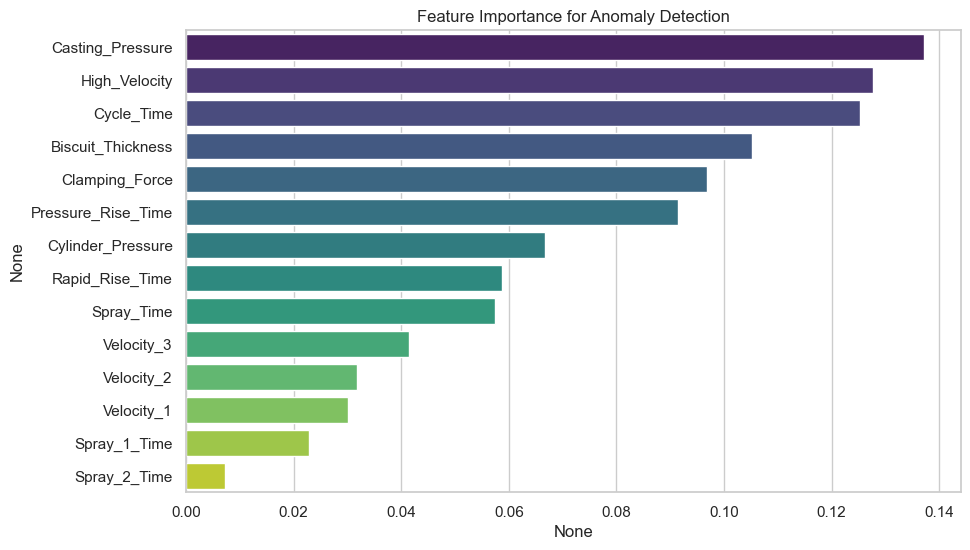

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 학습에 사용할 피처 선택
# 식별자, 타겟 변수, 기존에 생성한 빈(bin) 변수 제외
features = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness',
    'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time',
    'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time'
]

X = complete_data[features]
y = complete_data['Machine_Status']

# 2. 학습/테스트 데이터 분리 (불균형 데이터이므로 stratify 설정)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 랜덤 포레스트 모델 생성 및 학습
# 스텔스 불량을 더 잘 잡기 위해 class_weight를 'balanced'로 설정 가능
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 4. 예측 및 성능 평가
y_pred = rf_model.predict(X_test)

print("### Random Forest 모델 성능 평가 ###")
print(classification_report(y_test, y_pred))

# 5. 변수 중요도(Feature Importance) 확인
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Feature Importance for Anomaly Detection')
plt.show()